# Measuring the accuracy of random and stratified sampling for predicting the prevalence

We compare the predictions of infected individuals for the following sampling strategies in EpiOS:
- Random
- Age stratification
- Region stratification

Imports

In [1]:
import epios

from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from tqdm import tqdm

In [22]:
path = '.'
# This assumes the python venv is installed under EpiOS folder
columns = pd.read_csv(f'{path}/simulation_outputs/inf_status_history.csv', nrows=1).columns
dtype_dict = {columns[0]: float}
for col in columns[1:]:
    dtype_dict[col] = 'int8'
demo_data = pd.read_csv(f'{path}/simulation_outputs/demographics.csv', low_memory=True, dtype={'id': str, 'age': 'int8', 'location_x': float, 'location_y': float, 'kw_or_chr': str})
time_data = pd.read_csv(f'{path}/simulation_outputs/inf_status_history.csv', low_memory=True, dtype=dtype_dict)

In [23]:
def predict_base(post_process: epios.FastPostProcess, sample_size: int,
                 time_sample: List[int], comparison: bool,
                 sample_strategy: str) -> Tuple[np.array, ...]:
    """Uses the `Base` method from `epios.PostProcess` to predict prevalence
    from a sample.

    Returns
    -------
    Tuple[np.array, ...]
         Returns the times, true and predicted prevalence rates in a tuple to be
         used for further analysis
    """
    # Make prediction
    result, diff = post_process.predict.Base(sample_size=sample_size,
                                             time_sample=time_sample,
                                             comparison=comparison,
                                             gen_plot=False,
                                             sample_strategy=sample_strategy)

    # Find population size and get true data
    pop_size = len(post_process.demo_data)
    times, base_prediction = result[0], np.array(result[1])
    true = diff + np.array(result[1])*pop_size
    true_rate = true / pop_size
    base_prediction_age_groups = post_process.predict.result_ages
    base_prediction_regions = post_process.predict.result_regions

    return times, true_rate, base_prediction, base_prediction_age_groups, base_prediction_regions

In [24]:
def predict_age(post_process: epios.FastPostProcess, sample_size: int,
                 time_sample: List[int], comparison: bool,
                 sample_strategy: str) -> Tuple[np.array, ...]:
    """Uses the `Age` method from `epios.PostProcess` to predict prevalence
    from a sample.

    Returns
    -------
    Tuple[np.array, ...]
         Returns the times, true and predicted prevalence rates in a tuple to be
         used for further analysis
    """
    # Make prediction
    result, diff = post_process.predict.Age(sample_size=sample_size,
                                             time_sample=time_sample,
                                             comparison=comparison,
                                             gen_plot=False,
                                             sample_strategy=sample_strategy)

    # Find population size and get true data
    pop_size = len(post_process.demo_data)
    times, age_prediction = result[0], np.array(result[1])
    true_rate = diff + np.array(result[1])*pop_size
    age_prediction_age_groups = post_process.predict.result_ages
    age_prediction_regions = post_process.predict.result_regions

    return times, true_rate, age_prediction, age_prediction_age_groups, age_prediction_regions

In [25]:
def predict_region(post_process: epios.FastPostProcess, sample_size: int,
                 time_sample: List[int], comparison: bool,
                 sample_strategy: str) -> Tuple[np.array, ...]:
    """Uses the `Region` method from `epios.PostProcess` to predict prevalence
    from a sample.

    Returns
    -------
    Tuple[np.array, ...]
         Returns the times, true and predicted prevalence rates in a tuple to be
         used for further analysis
    """
    # Make prediction
    result, diff = post_process.predict.Region(sample_size=sample_size,
                                             time_sample=time_sample,
                                             comparison=comparison,
                                             gen_plot=False,
                                             sample_strategy=sample_strategy)

    # Find population size and get true data
    pop_size = len(post_process.demo_data)
    times, region_prediction = result[0], np.array(result[1])
    true_rate = diff + np.array(result[1])*pop_size
    region_prediction_age_groups = post_process.predict.result_ages
    region_prediction_regions = post_process.predict.result_regions

    return times, true_rate, region_prediction, region_prediction_age_groups, region_prediction_regions

### Finding samples using Random, Age, and Region methods

In [26]:
def rand(post_process: epios.FastPostProcess, sample_size: int,
                  time_sample: List[int], comparison: bool) -> Tuple[np.array, ...]:
    """This returns predictions from the random stratification,
    without plotting.

    Returns
    -------
    Tuple[np.array, ...]
        Times array, true results, predictions with random stratification
    """
    random = predict_base(post_process=post_process,
                               sample_size=sample_size,
                               time_sample=time_sample,
                               comparison=comparison,
                               sample_strategy='Random')
    times, true_rate, random_pred, random_pred_age_groups, random_pred_regions = random

    people_sampled = post_process.predict.people_sampled
    region_sampled = post_process.predict.region_sampled

    return times, true_rate, random_pred, random_pred_age_groups, random_pred_regions, people_sampled, region_sampled

In [27]:
def age(post_process: epios.FastPostProcess, sample_size: int,
                  time_sample: List[int], comparison: bool) -> Tuple[np.array, ...]:
    """This returns predictions from the age stratification, without plotting.

    Returns
    -------
    Tuple[np.array, ...]
        Times array, true results, predictions with age stratification
    """
    age_strat = predict_age(post_process=post_process,
                               sample_size=sample_size,
                               time_sample=time_sample,
                               comparison=comparison,
                               sample_strategy='Random')
    times, true_rate, age_pred, age_pred_age_groups, age_pred_regions = age_strat

    people_sampled = post_process.predict.people_sampled
    region_sampled = post_process.predict.region_sampled

    return times, true_rate, age_pred, age_pred_age_groups, age_pred_regions, people_sampled, region_sampled

In [28]:
def region(post_process: epios.FastPostProcess, sample_size: int,
                  time_sample: List[int], comparison: bool) -> Tuple[np.array, ...]:
    """This returns predictions from the region stratification,
    without plotting.

    Returns
    -------
    Tuple[np.array, ...]
        Times array, true results, predictions with region stratification
    """
    region = predict_region(post_process=post_process,
                            sample_size=sample_size,
                            time_sample=time_sample,
                            comparison=comparison,
                            sample_strategy='Random')
    times, true_rate, region_pred, region_pred_age_groups, region_pred_regions = region

    people_sampled = post_process.predict.people_sampled
    region_sampled = post_process.predict.region_sampled

    return times, true_rate, region_pred, region_pred_age_groups, region_pred_regions, people_sampled, region_sampled

### Calculating the true number of infections per age group

In [29]:
def count_people_by_age_group(demo_data, time_data, time_sample, num_age_group=17, age_group_width=5):
    """
    Count the true number of people within each age group that are infected.

    Parameters
    ----------
    demo_data: pandas.DataFrame
        Demographic data of the population
    time_data: pandas.DataFrame
        The infection data of the population at different time points
    time_sample: list
        A list of time points to sample the population
    num_age_group: int
        Number of age groups within the population
    age_group_width: int
        Number of ages within an age group

    Returns
    -------
    total_infections_age_groups: list[list, ...]
        A list containing a list of infection totals for each time point. Here,
        each list represents an age group
    total_by_age: list
        A list containing the total number of individuals in each age group
    """
    df = demo_data
    inf_history = time_data
    total_infections_age_groups = []
    total_by_age = []

    # Group data by age groups
    for i in range(num_age_group):
        min_age = i * age_group_width
        max_age = min_age + age_group_width
        if i == num_age_group - 1:
            max_age = float('inf')  # Last group includes age >= some threshold

        age_group_data = df[df['age'].between(min_age, max_age-0.01)]

        selected_columns = [col for col in inf_history.columns if str(col) in age_group_data['id'].astype(str).values]
        selected_data = inf_history[selected_columns]

        selected_data = selected_data.iloc[time_sample]

        people_by_age = len(selected_data.columns)
        infections_by_age_group = selected_data.apply(lambda row: row.isin(range(3, 9)).sum(), axis=1).tolist()
        total_infections_age_groups.append(infections_by_age_group)
        total_by_age.append(people_by_age)

    return total_infections_age_groups, total_by_age

### Calculating the true number of infections per region

In [30]:
def count_people_by_region(demo_data, time_data, time_sample):
    """
    Count the true number of people within each region that are infected.

    Parameters
    ----------
    demo_data: pandas.DataFrame
        Demographic data of the population
    time_data: pandas.DataFrame
        The infection data of the population at different time points
    time_sample: list
        A list of time points to sample the population

    Returns
    -------
    total_count_regions: list[list, ...]
        A list containing a list of infection totals for each time point. Here,
        each list represents a region
    total_by_region: list
        A list containing the total number of individuals in each region
    """
    inf_history = time_data
    last_row = demo_data.iloc[-1]
    region_id = int(last_row['id'].split('.')[0])
    total_by_region = []
    total_count_regions = []
    for region in range(region_id + 1):
        region_columns = [col for col in inf_history.columns if str(col).startswith(f'{region}.')]
        selected_data = inf_history[region_columns]
        selected_data = selected_data.iloc[time_sample]
        count_regions = selected_data.apply(lambda row: row.isin(range(3, 9)).sum(), axis=1).tolist()
        total_count_regions.append(count_regions)
        total_by_region.append(len(inf_history[region_columns].columns))

    return total_count_regions, total_by_region

In [31]:
time_sample = [num for num in range(90)]
# true_age_grouped_infections, total_by_age_groups = count_people_by_age_group(demo_data, time_data, time_sample)
# true_regional_infections, total_by_region = count_people_by_region(demo_data, time_data, time_sample)

### Initialising the post process

In [32]:
#from epios import FastPostProcess
# post_process = epios.PostProcess(demo_data=demo_data, time_data=time_data)
post_process = epios.FastPostProcess(demo_data=demo_data, time_data=time_data)

overall_prev = []
age_grouped_results = []
regional_results = []
age_grouped_people_sampled = []
region_grouped_people_sampled = []

### Sampling 

Here will we find the total prediction and the stratified predictions

In [ ]:
num_iters = 2
sample_size = 200
for j in range(num_iters):
    predictions = rand(post_process=post_process,
                       sample_size=sample_size,
                       time_sample=time_sample,
                       comparison=True)
    times, true_rate, random_pred, random_pred_age_groups, random_pred_regions, age_groups_sampled_rand, region_sampled_rand = predictions


    age_predictions = age(post_process=post_process,
                          sample_size=sample_size,
                          time_sample=time_sample,
                          comparison=True)
    age_pred, age_pred_age_groups, age_pred_regions, age_groups_sampled, region_sampled_age = age_predictions[2], age_predictions[3], age_predictions[4], age_predictions[5], age_predictions[6]


    region_predictions = region(post_process=post_process,
                                sample_size=sample_size,
                                time_sample=time_sample,
                                comparison=True)
    region_pred, region_pred_age_groups, region_pred_regions, age_groups_sampled_region, region_sampled_region = region_predictions[2], region_predictions[3], region_predictions[4], region_predictions[5], region_predictions[6]

    print(f"Iteration {j}")

    iteration_rand_result = {'Iteration': j,
                             'Random Stratification': np.array(random_pred, dtype='float64'),
                             'Age Stratification': np.array(age_pred, dtype='float64'),
                             'Region Stratification': np.array(region_pred, dtype='float64')}
    
    if j >= len(overall_prev):
        overall_prev.append(iteration_rand_result)

    # Create a dictionary representing the iteration result
    iteration_age_result = {'Iteration': j,
                            'Random Stratification': np.array(random_pred_age_groups, dtype='float64'),
                            'Age Stratification': np.array(age_pred_age_groups, dtype='float64'),
                            'Region Stratification': np.array(region_pred_age_groups, dtype='float64')}

    # Append the iteration result to the list
    if j >= len(age_grouped_results):
        age_grouped_results.append(iteration_age_result)

    iteration_region_result = {'Iteration': j,
                               'Base Stratification': np.array(random_pred_regions, dtype='float64'),
                               'Age Stratification': np.array(age_pred_regions, dtype='float64'),
                               'Region Stratification': np.array(region_pred_regions, dtype='float64')}

    if j >= len(regional_results):
        regional_results.append(iteration_region_result)

    iteration_people_sampled = {'Iteration': j,
                                'Random': age_groups_sampled_rand,
                                'Age': age_groups_sampled,
                                'Region': age_groups_sampled_region}
    
    if j >= len(age_grouped_people_sampled):
        age_grouped_people_sampled.append(iteration_people_sampled)

    iteration_region_sampled = {'Iteration': j,
                                'Random': region_sampled_rand,
                                'Age': region_sampled_age,
                                'Region': region_sampled_region}

    if j >= len(region_grouped_people_sampled):
        region_grouped_people_sampled.append(iteration_region_sampled)

overall_prev_df = pd.DataFrame(overall_prev)
age_results_df = pd.DataFrame(age_grouped_results)
regional_results_df = pd.DataFrame(regional_results)
age_grouped_people_sampled_df = pd.DataFrame(age_grouped_people_sampled)
region_grouped_people_sampled_df = pd.DataFrame(region_grouped_people_sampled)

### Multiple samples

We take $K$ samples in total such that the $k^{th}$ sample has $x_k$ positive tests out of $n_k$ individuals sampled. Each sample is taken from the same overall population and so the true prevalence $\theta$ is the same for each sample. Hence

$p(\theta|\textbf{x})=\theta^X(1-\theta)^{N-X}$ where $N=\sum_{k=1}^K{n_k}$, $X=\sum_{k=1}^K{x_k}$ are the total number of people tested and positive cases, respectively.

Given the sampling is random, there are $n_k=$ sample_size individuals sampled for each $k^{th}$ sample. Therefore, $N=$ sample_size*$K$

In [14]:
# Calculating the total number of positive tests from the samples
X_rand = []

for j in range(90): # Time steps
    x_rand = 0
    for i in range(num_iters): # Iterations
        x_rand += overall_prev_df.iloc[:]['Random Stratification'][i][j]*sample_size
    X_rand.append(x_rand)


### Sampling accuracy and precision

Here we calculate the fraction of days where each method's credible interval encompasses the true prevalence rate for that day, a measure of sampling accuracy. We also determine the size of the credible interval to calculate the sampling precision.

 Here, we use the results from the random sampling method.

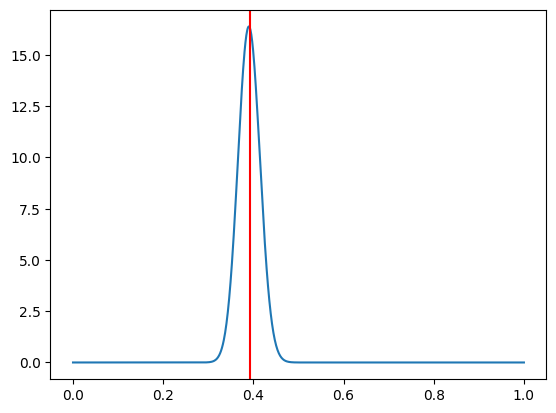

16.259117505774295
0.5442309111057498


In [15]:
# Plot scipy.stats.beta distribution
i = 20
p = scipy.stats.beta(X_rand[i]+1, (sample_size*num_iters)-X_rand[i] + 1)
x = np.linspace(0, 1, 1000)
plt.plot(x, p.pdf(x))
plt.axvline(x=true_rate[i], color='red')
plt.show()
print(p.pdf(true_rate[i]))
print(p.cdf(true_rate[i]))

In [16]:
# Random stratification for total prevalence
in_range = 0
total_width = 0
multiplication = 0
for i in range(90):
    p = scipy.stats.beta(X_rand[i]+1, (sample_size*num_iters)-X_rand[i] + 1)
    lower_bound, upper_bound = p.interval(0.95)
    width = upper_bound - lower_bound
    mean = p.mean()
    ci = width/mean
    total_width += ci
    multiplication += np.log(p.pdf(true_rate[i]))

    if lower_bound <= true_rate[i] <= upper_bound:
        in_range += 1
print(p.pdf(true_rate[i]))
print('Accuracy of random sampling:', np.round(in_range/90, 2))
print('Average CI width:', np.round(total_width/90, 2))
print('Average likelihood:', np.round(multiplication, 2))

8.841004060829547
Accuracy of random sampling: 0.93
Average CI width: 0.51
Average likelihood: 236.18


### Multiple age groups

We want to compare sampling methods for a stratified sampling approach with counts of $x_g$ in each age group. For multiple samples, each group may have a different true prevalence rate $\theta_g$. Therefore,

$p(\theta|\textbf{x})=\prod^G_{g=1}\theta_g^{x_g}(1-\theta_g)^{n_g-x_g}$

As before, we will investigate the sampling accuracy and precision of this sampling routine.

In [17]:
def calculate_fraction(prediction, sampled_group):
    in_range = 0
    total_width = 0
    for j in tqdm(range(90)):
    #for j in range(90): # Time steps
        x_summed = np.zeros(17)
        n_summed = np.zeros(17)
        for i in range(num_iters): # Iterations
            for k in range(17): # Age groups
                x = age_results_df.iloc[:][f'{prediction}'][i][k][j]*age_grouped_people_sampled_df.iloc[:][f'{sampled_group}'][i][j][k] # Multiplication due to the dataframe containing fractions of positive to total
                x_summed[k] += x
                n_summed[k] += age_grouped_people_sampled_df.iloc[:][f'{sampled_group}'][i][j][k]

        total_N = np.sum(n_summed)
        samples = []
        for _ in range(100):
            s = 0
            for k in range(17):
                s += (n_summed[k]/total_N) * scipy.stats.beta(x_summed[k]+1, n_summed[k]-x_summed[k]+1).rvs()
            samples.append(s)
        lower_bound = np.percentile(samples, 25)
        upper_bound = np.percentile(samples, 75)
        width = upper_bound - lower_bound
        mean = np.mean(samples)
        ci = width/mean
        total_width += ci
        
        if lower_bound <= true_rate[j] <= upper_bound:
            in_range += 1
    print('Accuracy of age stratified sampling:', np.round(in_range/90, 2))
    print('Average CI width:', np.round(total_width/90, 2))
    #plt.hist(samples, bins=30)

calculate_fraction('Age Stratification', 'Age')

100%|██████████| 90/90 [01:33<00:00,  1.04s/it]

Accuracy of age stratified sampling: 0.41
Average CI width: 0.12


### Multiple regions

We want to compare sampling methods for a stratified sampling approach with counts of $x_g$ in each region. For multiple samples, each group may have a different true prevalence rate $\theta_g$. Therefore,

$p(\theta|\textbf{x})=\prod^G_{g=1}\theta_g^{x_g}(1-\theta_g)^{n_g-x_g}$

As before, we will investigate the sampling accuracy and precision of this sampling routine.

In [18]:
def calculate_fraction(prediction, sampled_group):
    in_range = 0
    total_width = 0
    for j in tqdm(range(90)):
    #for j in range(90): # Time steps
        x_summed = np.zeros(12)
        n_summed = np.zeros(12)
        for i in range(num_iters): # Iterations
            for k in range(12): # Regions
                x = regional_results_df.iloc[:][f'{prediction}'][i][k][j]*region_grouped_people_sampled_df.iloc[:][f'{sampled_group}'][i][j][k] # Multiplication due to the dataframe containing fractions of positive to total
                x_summed[k] += x
                n_summed[k] += region_grouped_people_sampled_df.iloc[:][f'{sampled_group}'][i][j][k]

        total_N = np.sum(n_summed)
        samples = []
        for _ in range(100):
            s = 0
            for k in range(12):
                s += (n_summed[k]/total_N) * scipy.stats.beta(x_summed[k]+1, n_summed[k]-x_summed[k]+1).rvs()
            samples.append(s)
        lower_bound = np.percentile(samples, 25)
        upper_bound = np.percentile(samples, 75)
        width = upper_bound - lower_bound
        mean = np.mean(samples)
        ci = width/mean
        total_width += ci

        if lower_bound <= true_rate[j] <= upper_bound:
            in_range += 1
    print('Accuracy of region stratified sampling:', np.round(in_range/90, 2))
    print('Average CI width:', np.round(total_width/90, 2))
    #plt.hist(samples, bins=30)

calculate_fraction('Region Stratification', 'Region')

100%|██████████| 90/90 [00:56<00:00,  1.58it/s]

Accuracy of region stratified sampling: 0.28
Average CI width: 0.12


## Plots

We can see the distribution of individuals by age and region

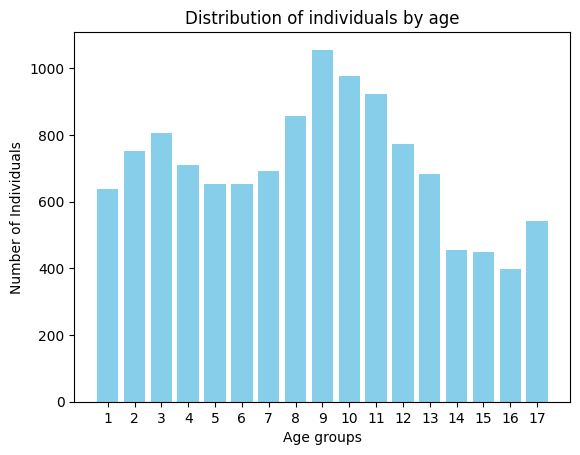

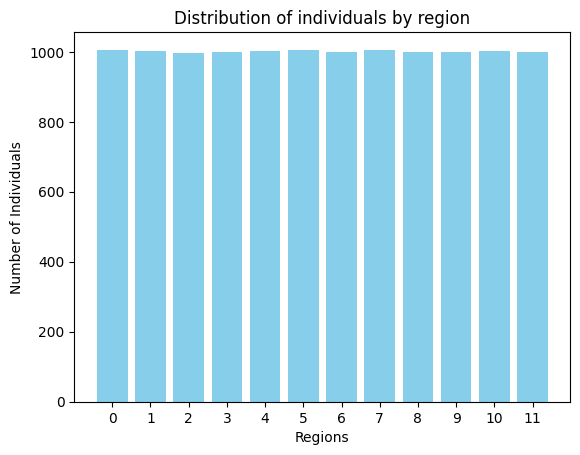

<Figure size 640x480 with 0 Axes>

In [19]:
age_groups = [_+1 for _ in range(len(total_by_age_groups))]
regions = [_ for _ in range(len(total_by_region))]
num_people = total_by_age_groups
num_people_regions = total_by_region

plt.bar(age_groups, num_people, color='skyblue')
plt.xlabel('Age groups')
plt.ylabel('Number of Individuals')
plt.title('Distribution of individuals by age')
plt.xticks(age_groups)
plt.show()
plt.clf()

plt.bar(regions, num_people_regions, color='skyblue')
plt.xlabel('Regions')
plt.ylabel('Number of Individuals')
plt.title('Distribution of individuals by region')
plt.xticks(regions)
plt.show()
plt.clf()

We can also show the distribution of infections over time by age group and region

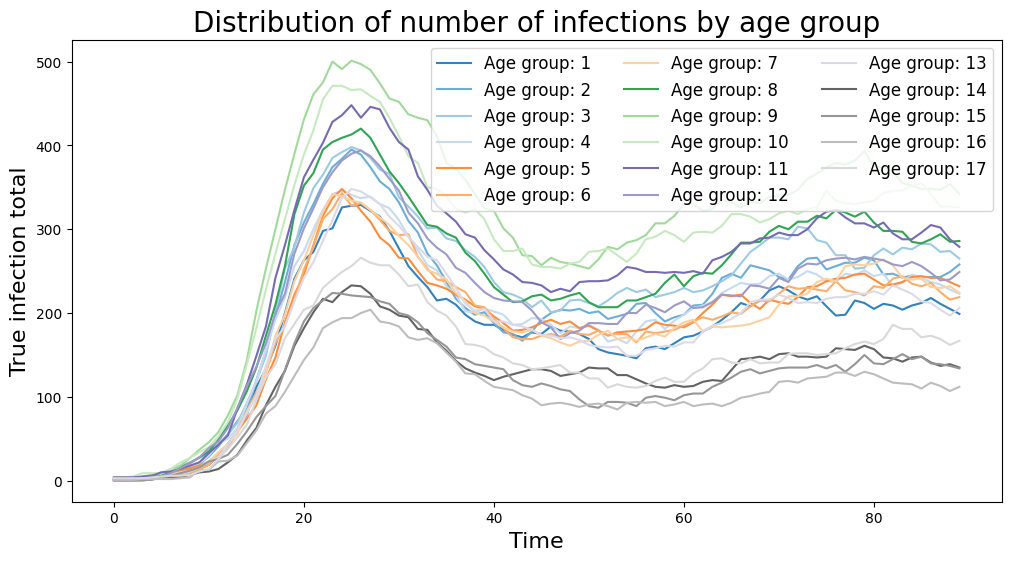

In [20]:
plt.figure(figsize=(12, 6))
cmap = plt.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, len(true_age_grouped_infections))]
for i, sublist in enumerate(true_age_grouped_infections):
    plt.plot(times, true_age_grouped_infections[i], label=f'Age group: {i+1}', color=colors[i])
plt.xlabel("Time", fontsize=16)
plt.ylabel("True infection total", fontsize=16)
plt.title("Distribution of number of infections by age group", fontsize=20)
plt.legend(fontsize=12, ncol=3)
plt.show()

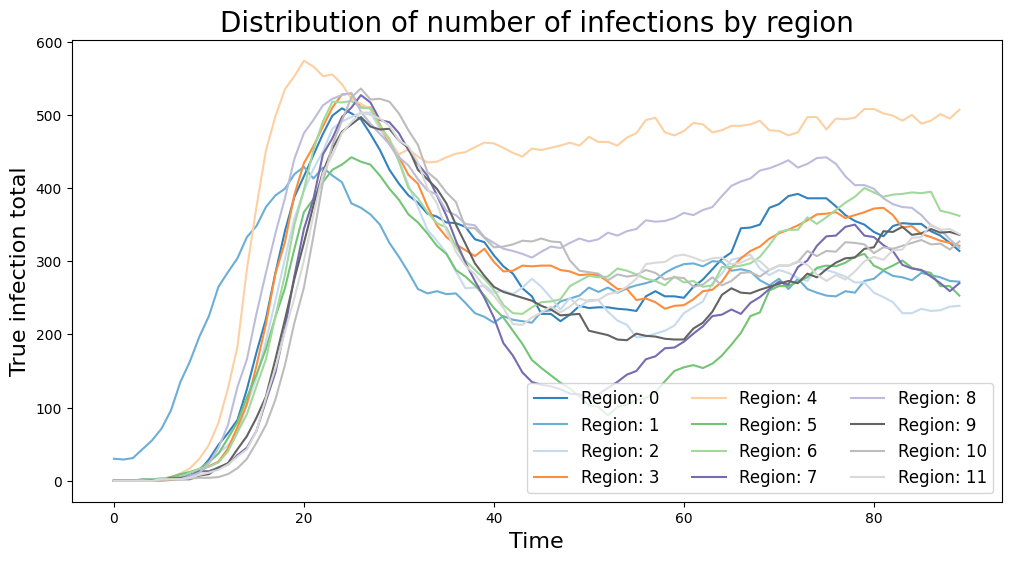

In [21]:
plt.figure(figsize=(12, 6))
cmap = plt.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, len(true_regional_infections))]
for i, sublist in enumerate(true_regional_infections):
    plt.plot(times, true_regional_infections[i], label=f'Region: {i}', color=colors[i])
plt.xlabel("Time", fontsize=16)
plt.ylabel("True infection total", fontsize=16)
plt.title("Distribution of number of infections by region", fontsize=20)
plt.legend(fontsize=12, ncol=3)
plt.show()